<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/non_linear_neural_network_algorithm_predict_age_gender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
! kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:17<00:00, 20.1MB/s]



In [3]:
import zipfile
zip_ref=zipfile.ZipFile('/content/utkface-new.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from keras import Sequential
from keras.models import Model
from keras.preprocessing  import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from keras.layers import *
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input

In [5]:
folder_path='/content/UTKFace'

In [6]:
age=[]
gender=[]
img_path=[]
for img in os.listdir(folder_path):
  age.append(int(img.split('_')[0]))
  gender.append(int(img.split('_')[1]))
  img_path.append(img)

In [7]:
len(age)

23708

In [8]:
df=pd.DataFrame({'age':age,'gender':gender,'img_path':img_path})

In [9]:
df.shape

(23708, 3)

In [10]:
df.head()



,age,gender,img_path
0,40,0,40_0_2_20170116193717434.jpg.chip.jpg
1,65,0,65_0_1_20170120134639935.jpg.chip.jpg
2,23,1,23_1_0_20170112234027666.jpg.chip.jpg
3,26,0,26_0_1_20170113152216521.jpg.chip.jpg
4,32,0,32_0_2_20170116164447916.jpg.chip.jpg


In [11]:
train_df=df.sample(frac=0.8,random_state=0)
test_df=df.drop(train_df.index)

In [12]:
train_df.shape

(18966, 3)

In [13]:
test_df.shape

(4742, 3)

In [14]:
# data_augmentation
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen=ImageDataGenerator(rescale=1./255)


In [15]:
input_dir = "/content/train"

output_dir = "/content/augmented_train"

os.makedirs(output_dir, exist_ok=True)

In [16]:
train_generator=train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age','gender'],
    target_size=(200,200),
    batch_size=32,
    class_mode='multi_output'
)

test_generator=test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age','gender'],
    target_size=(200,200),
    batch_size=32,
    class_mode='multi_output'
)


Found 18966 validated image filenames.
Found 4742 validated image filenames.


In [17]:
def generator_wrapper(generator):
    while True:
        images, labels = next(generator)

        yield images, {
            "age": labels[0],
            "gender": labels[1]
        }

In [18]:
train_ds = tf.data.Dataset.from_generator(
    lambda: generator_wrapper(train_generator),
    output_signature=(
        tf.TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32),
        {
            "age": tf.TensorSpec(shape=(None,), dtype=tf.float32),
            "gender": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        },
    ),
)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator_wrapper(test_generator),
    output_signature=(
        tf.TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32),
        {
            "age": tf.TensorSpec(shape=(None,), dtype=tf.float32),
            "gender": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        },
    ),
)

In [20]:
vggnet=VGG16(input_shape=(200,200,3),include_top=False)
vggnet.trainable = False

In [21]:
x = vggnet.output

x = Flatten()(x)

x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)

age_output = Dense(
    1,
    activation='linear',
    name='age'
)(x)

gender_output = Dense(
    1,
    activation='sigmoid',
    name='gender'
)(x)

model = Model(
    inputs=vggnet.input,
    outputs=[age_output, gender_output]
)


In [ ]:
model=Model(inputs=vggnet.input,outputs=[output1,output2])

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 24,678,722 (94.14 MB)

 Trainable params: 9,964,034 (38.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

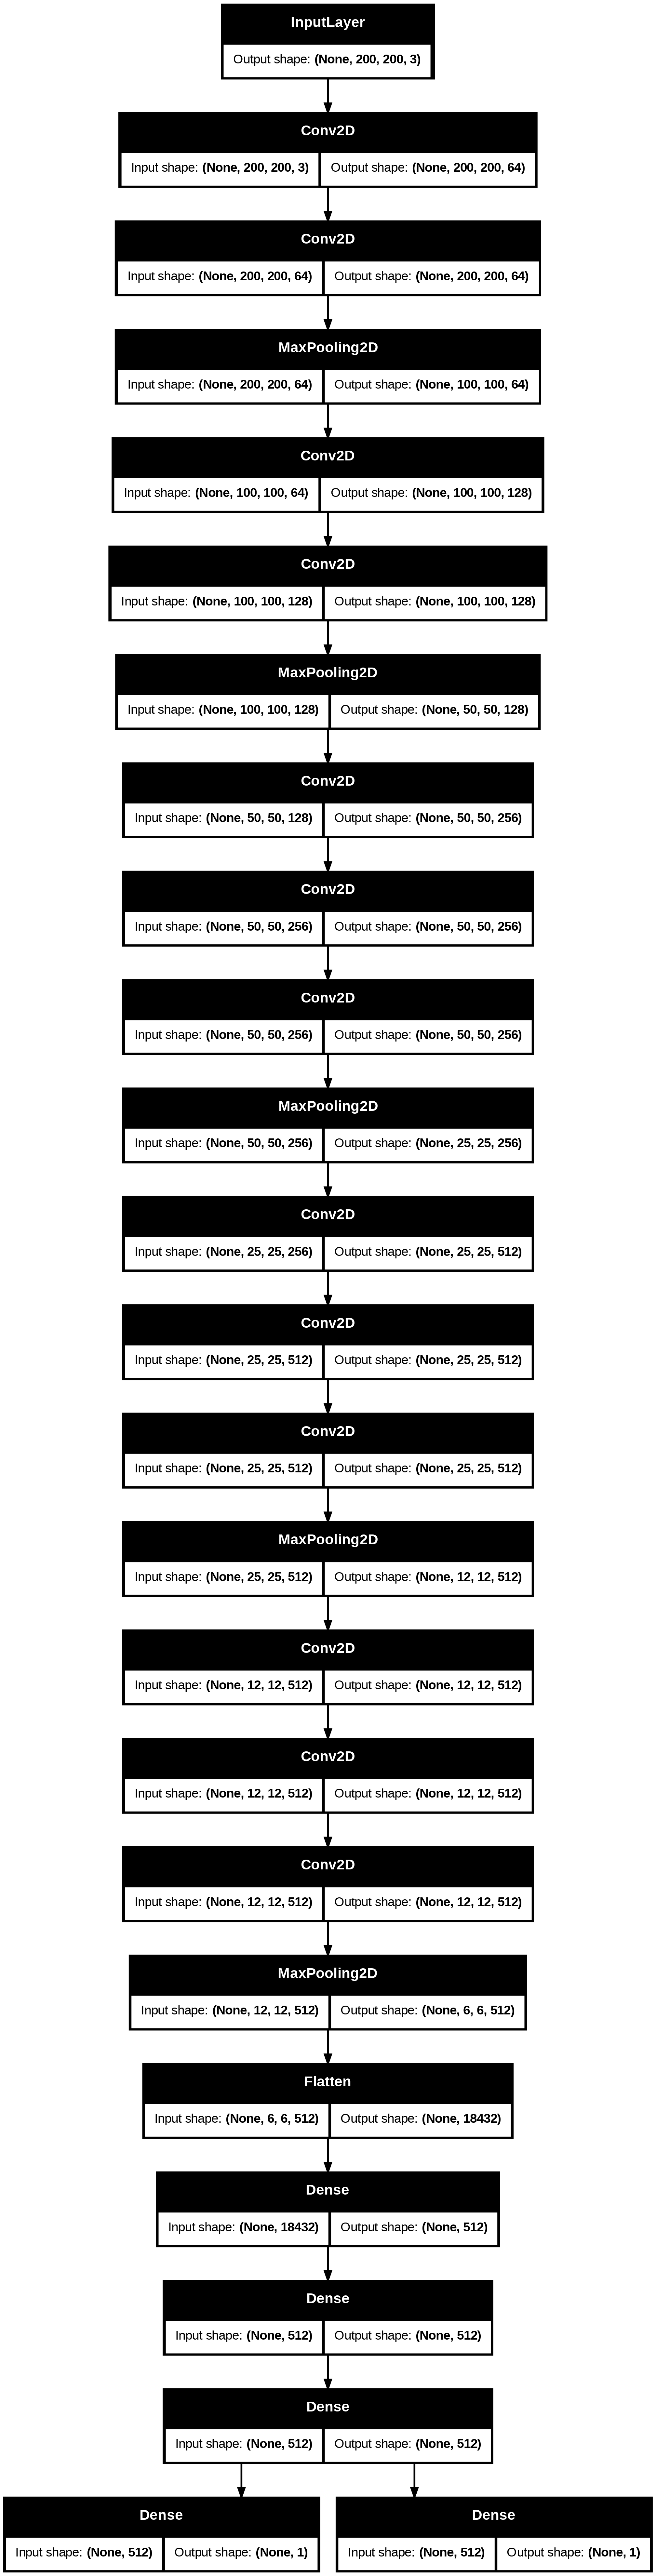

In [ ]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)

In [22]:
model.compile(
    optimizer='adam',

    loss={
        'age': 'mse',
        'gender': 'binary_crossentropy'
    },

    metrics={
        'age': ['mae'],
        'gender': ['accuracy']
    }
)

In [23]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator)
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 285s 453ms/step - age_loss: 213.9859 - age_mae: 11.0259 - gender_accuracy: 0.6144 - gender_loss: 0.6645 - loss: 214.6836 - val_age_loss: 185.2762 - val_age_mae: 10.5944 - val_gender_accuracy: 0.6594 - val_gender_loss: 0.6358 - val_loss: 185.9246
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 251s 424ms/step - age_loss: 170.5856 - age_mae: 9.6688 - gender_accuracy: 0.6317 - gender_loss: 0.6455 - loss: 171.2833 - val_age_loss: 135.8880 - val_age_mae: 8.4188 - val_gender_accuracy: 0.6461 - val_gender_loss: 0.6491 - val_loss: 136.1544
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 252s 426ms/step - age_loss: 159.5647 - age_mae: 9.3319 - gender_accuracy: 0.6339 - gender_loss: 0.6466 - loss: 160.2215 - val_age_loss: 131.0624 - val_age_mae: 8.3682 - val_gender_accuracy: 0.6428 - val_gender_loss: 0.6301 - val_loss: 131.5336
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 250s 422ms/step - age_loss: 159.2392 - age_mae: 9.2619 - gender_accuracy: 0.6345 - gender_loss: 0.6427 - l

In [29]:
print(history.history.keys())


dict_keys(['age_loss', 'age_mae', 'gender_accuracy', 'gender_loss', 'loss', 'val_age_loss', 'val_age_mae', 'val_gender_accuracy', 'val_gender_loss', 'val_loss'])


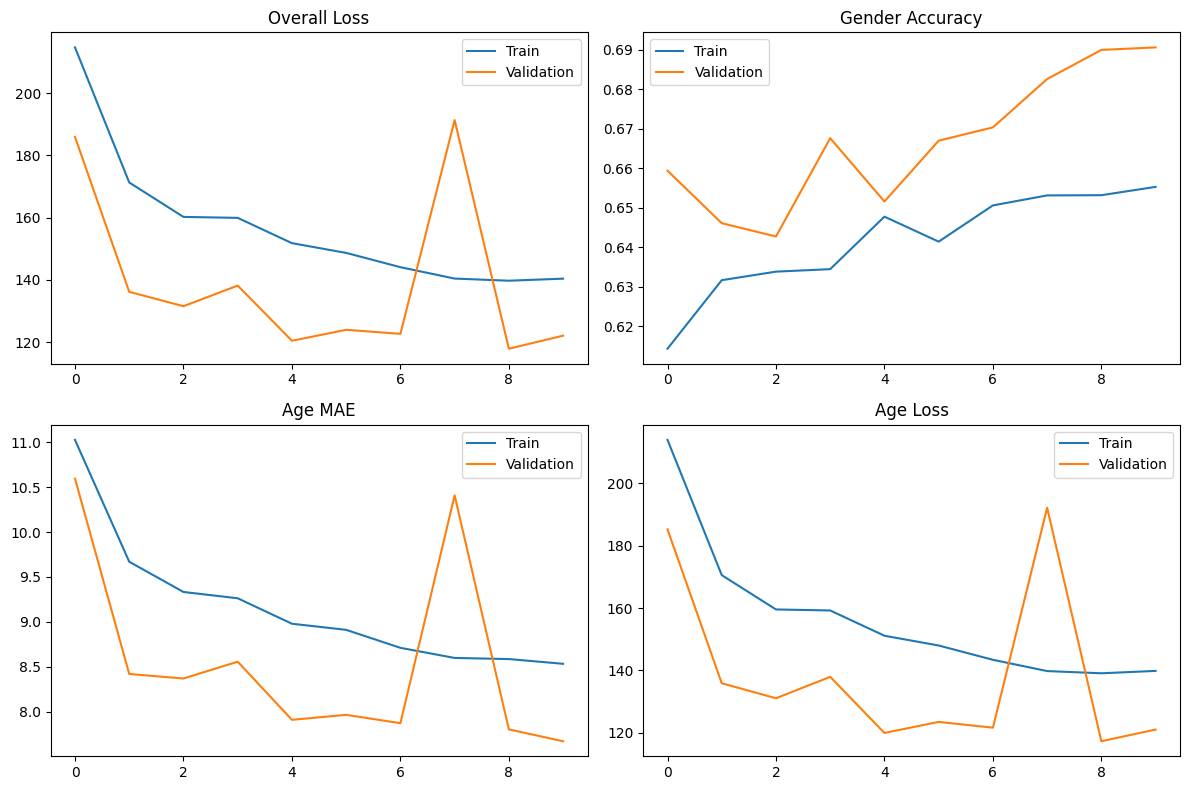

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Overall Loss
ax[0,0].plot(history.history['loss'], label='Train')
ax[0,0].plot(history.history['val_loss'], label='Validation')
ax[0,0].set_title("Overall Loss")
ax[0,0].legend()

# Gender Accuracy
ax[0,1].plot(history.history['gender_accuracy'], label='Train')
ax[0,1].plot(history.history['val_gender_accuracy'], label='Validation')
ax[0,1].set_title("Gender Accuracy")
ax[0,1].legend()

# Age MAE
ax[1,0].plot(history.history['age_mae'], label='Train')
ax[1,0].plot(history.history['val_age_mae'], label='Validation')
ax[1,0].set_title("Age MAE")
ax[1,0].legend()

# Age Loss
ax[1,1].plot(history.history['age_loss'], label='Train')
ax[1,1].plot(history.history['val_age_loss'], label='Validation')
ax[1,1].set_title("Age Loss")
ax[1,1].legend()

plt.tight_layout()
plt.show()